In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
from PIL import Image

In [2]:
from viz_utils import plot_costmap_with_info

## Setting up the directories

In [6]:
# SCENE_DIR = Path("/home/onyx/work_dirs/vanshg/navigation/sg_habitat/data/hm3d_iin_val/DYehNKdT76V_0000000_toilet_115_")
SCENE_DIR = Path("/scratch2/public_scratch/toponav/indoor-topo-loc/datasets/hm3d_navigation/hm3d_iin_val_320x240/cvZr5TUy5C5_0000026_sofa_370_")

SCENE_IMG_DIR = SCENE_DIR / "images"
MAP_BASE_DIR = Path(os.path.abspath("/scratch2/public_scratch/vanshg/mast3r-nav/hm3d_val_mapping"))

SCENE_NAME = "Nfvxx8J5NCo_0000000_tv_monitor_31_"
SCENE_MAP_DIR = MAP_BASE_DIR / SCENE_NAME

## Loading and Plotting the training costmaps


Costmaps data keys: ['costmaps', 'metadata']


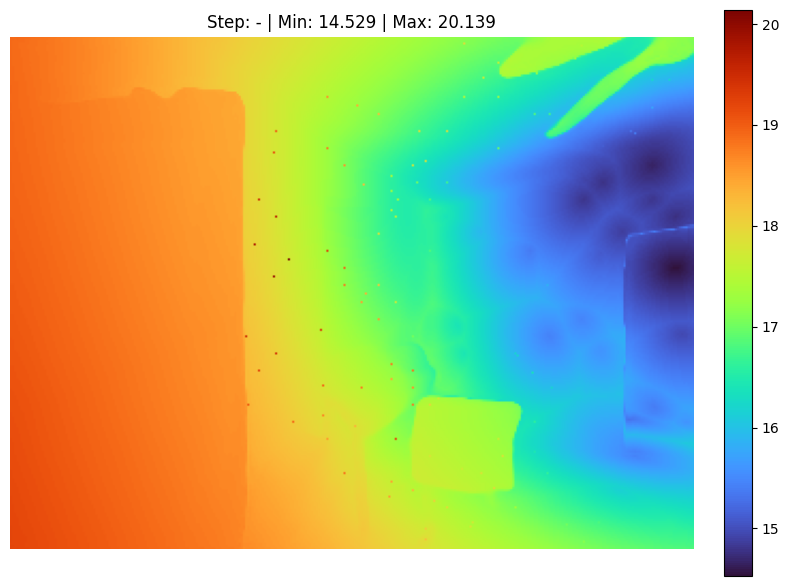

In [9]:
costmaps_file = SCENE_MAP_DIR / "costmaps_320x240_EC_EMST_SINGLE_NC_NONE_NCF_10.npz"

costmaps_data = np.load(costmaps_file)
print("Costmaps data keys:", costmaps_data.files)
img_costmaps = costmaps_data["costmaps"]

plot_costmap_with_info(img_costmaps[0])

In [11]:
costmap_metadata = costmaps_data["metadata"]
print(costmap_metadata)

{"goal_img_idx": 82, "goal_pixel": [154, 60], "goal_node_id": 6316954, "cfg": {"image": {"width": 320, "height": 240, "hfov": 120}, "model": {"name": "mast3r", "path": "/home/onyx/work_dirs/vanshg/navigation/sg_habitat/libs/matcher/image_matching_models/matching/model_weights/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric.pth", "device": "cuda", "subsample_or_initxy1": 8}, "graph": {"inter_image_match_window_size": 3, "edge_culling_mode": "EMST_SINGLE", "node_culling_mode": "NONE", "node_culling_factor": 10}, "processing": {"subsample_start_idx": 0, "subsample_end_idx": null, "subsample_step": 1, "force_recompute_graph": true, "force_recompute_masks": false, "copy_images": false}, "compression": {"enabled": true, "chunk_size": 1073741824}, "scenes": {"base_dir": "/scratch2/public_scratch/toponav/indoor-topo-loc/datasets/hm3d_navigation/hm3d_iin_val_320x240", "multi_scene": true, "base_out_dir": "/scratch2/public_scratch/vanshg/mast3r-nav/hm3d_val_mapping", "scene_name": "q3zU7Yy5E5s_

In [6]:
COSTMAP_VIZ_DIR = MAP_DIR / "costmap_viz"
COSTMAP_VIZ_DIR.mkdir(exist_ok=True, parents=True)

In [7]:
num_images = img_costmaps.shape[0]

# Visualize and save costmaps with info
for i in range(num_images):
    costmap = img_costmaps[i]
    img_filename = f"costmap_{i:04d}.png"
    rgb_img_filename = SCENE_IMG_DIR / f"{i:05d}.png"
    rgb_img = cv2.imread(str(rgb_img_filename))
    save_path = COSTMAP_VIZ_DIR / img_filename
    plot_costmap_with_info(costmap, step_id=i, save_path=save_path)